# 1. DLinear reconstruction

In this notebook we reconstruct DLinear on the Weather dataset and
compare our result with the paper.

- **Task:** supervised multivariate forecasting
- **Sampling frequency:** 10 minutes
- **Input:** 336 observations (56 hours)
- **Output:** 96 observations (16 hours)
- **Variables:** 21 weather measurements

The notebook follows the full first stage of the project: data checks,
preprocessing, temporal split, a simple baseline, training, and evaluation.

## 1. Setup

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / "pyproject.toml").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from ts_project.baselines import seasonal_naive_forecast
from ts_project.data import prepare_weather, build_weather_window_datasets
from ts_project.models import DLinear
from ts_project.training import seed_everything, train_forecaster

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "weather.csv"
INPUT_LENGTH = 336
HORIZON = 96
BATCH_SIZE = 16
SEED = 2021
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)

Device: cuda


## 2. Load and check the data

The loader parses the date column, converts every forecasting variable to
a numeric value, and checks for missing or infinite values. We also inspect
the time index before deciding whether any cleaning is needed.

In [2]:
weather = prepare_weather(DATA_PATH)
time_differences = weather.raw.index.to_series().diff().dropna()

audit = pd.Series(
    {
        "rows": len(weather.raw),
        "variables": len(weather.channel_names),
        "start": weather.raw.index.min(),
        "end": weather.raw.index.max(),
        "missing values": int(weather.raw.isna().sum().sum()),
        "infinite values": int(np.isinf(weather.raw.to_numpy()).sum()),
        "duplicate timestamps": int(weather.raw.index.duplicated().sum()),
        "most common interval": time_differences.mode().iloc[0],
        "non-10-minute intervals": int((time_differences.dt.total_seconds() != 600).sum()),
    },
    name="Weather audit",
)
audit

rows                                     52696
variables                                   21
start                      2020-01-01 00:10:00
end                        2021-01-01 00:00:00
missing values                               0
infinite values                              0
duplicate timestamps                         1
most common interval           0 days 00:10:00
non-10-minute intervals                      2
Name: Weather audit, dtype: object

The supplied benchmark contains one duplicate timestamp and one gap. We do
not resample or fill them because the paper's implementation treats the file
as an equally spaced row sequence. Keeping it unchanged gives the fairest
comparison with the paper. No extra calendar features are used by DLinear.

## 3. Chronological split and scaling

In [3]:
split_table = pd.DataFrame(
    [
        {
            "split": name,
            "rows": len(weather.split(name)),
            "start": weather.split(name).index.min(),
            "end": weather.split(name).index.max(),
        }
        for name in ("train", "validation", "test")
    ]
)
display(split_table)

print("Mean of scaled training variables:",
      abs(weather.split("train", scaled=True).mean()).max())

,split,rows,start,end
0,train,36887,2020-01-01 00:10:00,2020-09-13 05:10:00
1,validation,5270,2020-09-13 05:20:00,2020-10-19 19:30:00
2,test,10539,2020-10-19 19:40:00,2021-01-01 00:00:00


Mean of scaled training variables: 5.633950696861065e-15


We use the official chronological 70%/10%/20% split. `StandardScaler` is
fitted only on the training observations and then applied to validation and
test. This prevents future information from entering preprocessing.

## 4. Forecasting windows

In [4]:
datasets = build_weather_window_datasets(
    weather,
    input_length=INPUT_LENGTH,
    prediction_length=HORIZON,
)
loaders = {
    "train": DataLoader(datasets["train"], batch_size=BATCH_SIZE, shuffle=True, drop_last=True),
    "validation": DataLoader(datasets["validation"], batch_size=BATCH_SIZE, shuffle=True, drop_last=True),
    "test": DataLoader(datasets["test"], batch_size=BATCH_SIZE, shuffle=False, drop_last=False),
}

pd.Series({name: len(dataset) for name, dataset in datasets.items()}, name="windows")

train         36456
validation     5175
test          10444
Name: windows, dtype: int64

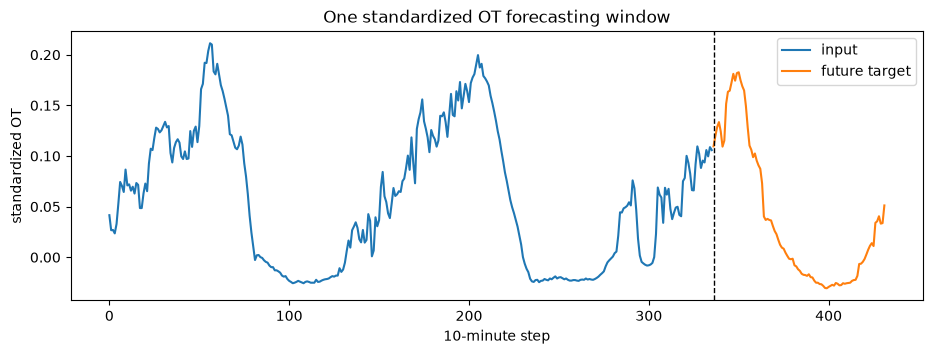

In [5]:
example_input, example_target = datasets["validation"][0]
channel = weather.channel_names.index("OT")

plt.figure(figsize=(11, 3.5))
plt.plot(range(INPUT_LENGTH), example_input[:, channel], label="input")
plt.plot(
    range(INPUT_LENGTH, INPUT_LENGTH + HORIZON),
    example_target[:, channel],
    label="future target",
)
plt.axvline(INPUT_LENGTH, color="black", linestyle="--", linewidth=1)
plt.title("One standardized OT forecasting window")
plt.xlabel("10-minute step")
plt.ylabel("standardized OT")
plt.legend()
plt.show()

Each window uses the previous 336 rows to predict the following 96 rows.
Validation and test inputs may use earlier observations as context, but all
forecast targets remain inside their own split.

## 5. Seasonal-naive baseline

Weather is sampled six times per hour, so one day contains 144 observations.
The seasonal-naive forecast repeats the most recent observed day. It has no
learned parameters and gives us a simple reference point.

In [6]:
@torch.inference_mode()
def evaluate_predictions(predict_batch, loader):
    squared_sum = absolute_sum = 0.0
    count = 0
    for inputs, targets in loader:
        predictions = predict_batch(inputs, targets)
        errors = predictions - targets
        squared_sum += errors.square().sum().item()
        absolute_sum += errors.abs().sum().item()
        count += errors.numel()
    mse = squared_sum / count
    return {"MSE": mse, "MAE": absolute_sum / count, "RMSE": mse**0.5}

baseline_metrics = evaluate_predictions(
    lambda inputs, targets: seasonal_naive_forecast(
        inputs, HORIZON, season_length=144
    ),
    loaders["test"],
)
baseline_metrics

{'MSE': 0.31670659721547373,
 'MAE': 0.28795598952561646,
 'RMSE': 0.5627669119764183}

## 6. DLinear

DLinear first separates every input channel into a moving-average trend and
a remainder:

$$
T=MA_{25}(X), \qquad R=X-T.
$$

Two shared linear layers map the full 336-step history directly to all 96
future steps, and their forecasts are added:

$$
\hat{Y}=W_RR+W_TT.
$$

The training objective is mean squared error. We use Adam, learning rate
0.0001 (1e-4), at most 10 epochs, and early stopping with patience 3. The best
checkpoint is selected by validation MSE.

In [7]:
seed_everything(SEED)
model = DLinear(
    input_length=INPUT_LENGTH,
    prediction_length=HORIZON,
    channels=len(weather.channel_names),
    moving_average=25,
    individual=False,
)
print("Trainable parameters:", sum(p.numel() for p in model.parameters()))

Trainable parameters: 64704


## 7. Train the reconstruction

In [8]:
seed_everything(SEED)
training = train_forecaster(
    model,
    loaders["train"],
    loaders["validation"],
    device=DEVICE,
    learning_rate=1e-4,
    max_epochs=10,
    patience=3,
    verbose=True,
)
history = pd.DataFrame(training.history)
history

Epoch   1/10 | train MSE 0.506181 | validation MSE 0.433110 | lr 1.00e-04


Epoch   2/10 | train MSE 0.464539 | validation MSE 0.430417 | lr 1.00e-04


Epoch   3/10 | train MSE 0.457825 | validation MSE 0.426956 | lr 5.00e-05


Epoch   4/10 | train MSE 0.455450 | validation MSE 0.426791 | lr 2.50e-05


Epoch   5/10 | train MSE 0.454530 | validation MSE 0.427713 | lr 1.25e-05


Epoch   6/10 | train MSE 0.454033 | validation MSE 0.425668 | lr 6.25e-06


Epoch   7/10 | train MSE 0.453783 | validation MSE 0.426106 | lr 3.13e-06


Epoch   8/10 | train MSE 0.453680 | validation MSE 0.425862 | lr 1.56e-06


Epoch   9/10 | train MSE 0.452719 | validation MSE 0.426247 | lr 7.81e-07


,epoch,learning_rate,train_mse,validation_mse
0,1,1.000000e-04,0.506181,0.433110
1,2,1.000000e-04,0.464539,0.430417
2,3,5.000000e-05,0.457825,0.426956
3,4,2.500000e-05,0.455450,0.426791
4,5,1.250000e-05,0.454530,0.427713
5,6,6.250000e-06,0.454033,0.425668
6,7,3.125000e-06,0.453783,0.426106
7,8,1.562500e-06,0.453680,0.425862
8,9,7.812500e-07,0.452719,0.426247


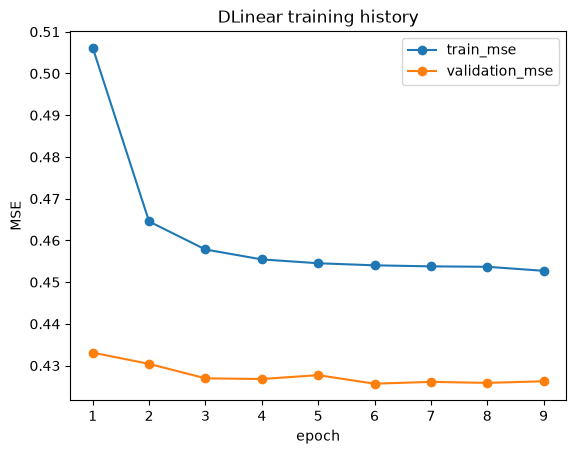

In [9]:
history.plot(
    x="epoch",
    y=["train_mse", "validation_mse"],
    marker="o",
    title="DLinear training history",
    ylabel="MSE",
)
plt.show()

## 8. Reconstruction results

MSE gives more weight to large errors. MAE is the mean absolute error, and
RMSE is the square root of MSE. All three are calculated over every test
window, forecast step, and variable in standardized space.

In [10]:
model_metrics = evaluate_predictions(
    lambda inputs, targets: model(inputs.to(DEVICE)).cpu(),
    loaders["test"],
)

comparison = pd.DataFrame(
    [
        {"Model": "Paper DLinear", "MSE": 0.176, "MAE": 0.237, "RMSE": 0.176**0.5},
        {"Model": "Seasonal naive", **baseline_metrics},
        {"Model": "Our DLinear reconstruction", **model_metrics},
    ]
)

relative_comparison = pd.DataFrame(
    {
        "Metric": ["MSE", "MAE", "RMSE"],
        "Paper": comparison.loc[0, ["MSE", "MAE", "RMSE"]].to_numpy(),
        "Our reconstruction": comparison.loc[2, ["MSE", "MAE", "RMSE"]].to_numpy(),
    }
)
relative_comparison["Relative difference (%)"] = 100 * (
    relative_comparison["Our reconstruction"] - relative_comparison["Paper"]
) / relative_comparison["Paper"]

display(comparison)
relative_comparison

,Model,MSE,MAE,RMSE
0,Paper DLinear,0.176000,0.237000,0.419524
1,Seasonal naive,0.316707,0.287956,0.562767
2,Our DLinear reconstruction,0.174205,0.233328,0.417379


,Metric,Paper,Our reconstruction,Relative difference (%)
0,MSE,0.176,0.174205,-1.019633
1,MAE,0.237,0.233328,-1.549388
2,RMSE,0.419524,0.417379,-0.511123


## 9. Conclusion

Our expected seed-2021 result is MSE 0.17421 and MAE 0.23333, compared
with 0.176 and 0.237 in the paper. This is a relative difference of -1.02%
for MSE and -1.55% for MAE, meaning that our errors are slightly lower. The
small difference can come from the random seed, software version, and low-level
GPU behavior. The reconstruction is close enough to use as the baseline for
our improvement.